# Fresh Retail: Starter Notebook

This notebook accompanies the **Introduction** slide deck (`FreshRetail_Introduction.pptx`). It provides a shared data pipeline for both tracks, then produces the exact outputs previewed in the showcase slides.

**Run sections 1–4 first** (shared setup), then run the section for your track:

| Section | Track | What you produce |
|---------|-------|-----------------|
| 5. Operations | Ops | Temporal profiles, heatmaps, KPIs, hourly patterns |
| 6. Data Science | DS | WAPE baselines, forecast overlays, demand recovery, error analysis |

Both tracks use the same dataset, same helper functions, and same time split.

- **Operations Track**: O1 (Diagnosis) or O2 (Decision)
- **Data Science Track**: D1 (Direct benchmark) or D2 (Recovery first)

**Dataset**: [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K)

---
## 1. Setup and Data Download

In [2]:
# Run this cell on Google Colab (already installed locally)
%pip install -q pandas pyarrow matplotlib seaborn datasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Setup complete.")

Setup complete.


In [4]:
from datasets import load_dataset

print("Downloading FreshRetailNet-50K from Hugging Face...")
ds = load_dataset("Dingdong-Inc/FreshRetailNet-50K")
print(ds)

# Convert to pandas
train_raw = ds["train"].to_pandas()
eval_raw = ds["eval"].to_pandas()

print(f"\nTrain: {train_raw.shape}, Eval: {eval_raw.shape}")
print(f"Columns: {list(train_raw.columns)}")

DatasetDict({
    train: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 4500000
    })
    eval: Dataset({
        features: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'stock_hour6_22_cnt', 'hours_stock_status', 'discount', 'holiday_flag', 'activity_flag', 'precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level'],
        num_rows: 350000
    })
})

Train: (4500000, 19), Eval: (350000, 19)
Columns: ['city_id', 'store_id', 'management_group_id', 'first_category_id', 'second_category_id', 'third_category_id', 'product_id', 'dt', 'sale_amount', 'hours_sale', 'sto

---
## 2. Data Preparation

In [5]:
def prepare_panel(df: pd.DataFrame) -> pd.DataFrame:
    """Prepare the raw HF dataset into a clean analysis panel."""
    df = df.copy()

    # Parse date
    df["dt"] = pd.to_datetime(df["dt"])
    df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)

    # Create series_id (unique store x product combination)
    series_keys = df[["store_id", "product_id"]].drop_duplicates().reset_index(drop=True)
    series_keys["series_id"] = range(1, len(series_keys) + 1)
    df = df.merge(series_keys, on=["store_id", "product_id"], how="left")

    # Create day index (days since start)
    min_date = df["dt"].min()
    df["day_idx"] = (df["dt"] - min_date).dt.days + 1

    n_series = df["series_id"].nunique()
    n_days = df["day_idx"].nunique()
    print(f"Prepared {len(df):,} rows \u2014 {n_series:,} series x {n_days} days")
    print(f"Date range: {df['dt'].min().date()} to {df['dt'].max().date()}")
    return df


history = prepare_panel(train_raw)
pd.set_option('display.max_columns', None)   # show all columns
pd.set_option('display.width', None)         # avoid line wrapping
pd.set_option('display.max_colwidth', None)  # optional: full cell contents

history.head()

Prepared 4,500,000 rows — 50,000 series x 90 days
Date range: 2024-03-28 to 2024-06-25


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,series_id,day_idx
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,1.6999,15.48,73.54,1.97,1,1
1,0,0,2,29,78,82,4,2024-03-29,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,3.0190,15.08,76.56,1.71,1,2
2,0,0,2,29,78,82,4,2024-03-30,5.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.4, 0.3, 0.0, 0.0, 1.1, 0.2, 0.1, 1.3, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]",0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,1,1,2.0942,15.91,76.47,1.73,1,3
3,0,0,2,29,78,82,4,2024-03-31,4.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.5, 0.2, 0.0, 0.0, 0.3, 1.2, 0.3, 0.6, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.879,1,1,1.5618,16.13,77.40,1.76,1,4
4,0,0,2,29,78,82,4,2024-04-01,0.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,0,1,3.5386,15.37,78.26,1.25,1,5


---
## 3. Shared Functions: flag_censoring, make_features, time_split

In [6]:
def flag_censoring(df: pd.DataFrame) -> pd.DataFrame:
    """Add censoring flags based on stockout hours."""
    df = df.copy()
    df["is_censored"] = (df["stock_hour6_22_cnt"] > 0).astype(int)
    df["censoring_severity"] = df["stock_hour6_22_cnt"] / 16
    print(f"Censored rows: {df['is_censored'].sum():,} / {len(df):,} ({df['is_censored'].mean():.1%})")
    return df


def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add lag and rolling features for EDA and forecasting."""
    df = df.sort_values(["series_id", "day_idx"]).copy()
    grp = df.groupby("series_id")["sale_amount"]
    df["sales_lag1"] = grp.shift(1)
    df["sales_lag7"] = grp.shift(7)
    df["sales_roll7"] = grp.transform(lambda x: x.rolling(7, min_periods=1).mean())
    df["sales_roll28"] = grp.transform(lambda x: x.rolling(28, min_periods=1).mean())
    df["psd"] = grp.transform("mean")  # per-series daily mean
    return df


def time_split(df: pd.DataFrame, horizon: int = 7) -> tuple:
    """Split into train and validation by time. Validation = last `horizon` days."""
    min_day = df["day_idx"].min()
    max_day = df["day_idx"].max()
    val_start = max_day - horizon + 1
    train = df[df["day_idx"] < val_start].copy()
    val = df[df["day_idx"] >= val_start].copy()
    print(f"Train: day {min_day}..{val_start - 1} ({len(train):,} rows), Val: day {val_start}..{max_day} ({len(val):,} rows)")
    return train, val

In [7]:
# Apply shared pipeline
history = flag_censoring(history)
history = make_features(history)

train, val = time_split(history, horizon=7)
print(f"\nValidation window: day {val['day_idx'].min()} to {val['day_idx'].max()}")

history.head()

Censored rows: 1,992,006 / 4,500,000 (44.3%)
Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)

Validation window: day 84 to 90


,city_id,store_id,management_group_id,first_category_id,second_category_id,third_category_id,product_id,dt,sale_amount,hours_sale,stock_hour6_22_cnt,hours_stock_status,discount,holiday_flag,activity_flag,precpt,avg_temperature,avg_humidity,avg_wind_level,series_id,day_idx,is_censored,censoring_severity,sales_lag1,sales_lag7,sales_roll7,sales_roll28,psd
0,0,0,2,29,78,82,4,2024-03-28,0.5,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",13,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,1.6999,15.48,73.54,1.97,1,1,1,0.8125,NaN,NaN,0.500000,0.500000,2.701111
1,0,0,2,29,78,82,4,2024-03-29,1.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.3, 0.8, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",5,"[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]",0.882,0,1,3.0190,15.08,76.56,1.71,1,2,1,0.3125,0.5,NaN,0.900000,0.900000,2.701111
2,0,0,2,29,78,82,4,2024-03-30,5.3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.7, 1.4, 0.3, 0.0, 0.0, 1.1, 0.2, 0.1, 1.3, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0]",0,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,1,1,2.0942,15.91,76.47,1.73,1,3,0,0.0000,1.3,NaN,2.366667,2.366667,2.701111
3,0,0,2,29,78,82,4,2024-03-31,4.2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.5, 0.2, 0.0, 0.0, 0.3, 1.2, 0.3, 0.6, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.879,1,1,1.5618,16.13,77.40,1.76,1,4,0,0.0000,5.3,NaN,2.825000,2.825000,2.701111
4,0,0,2,29,78,82,4,2024-04-01,0.7,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0, 0.0]",0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.882,0,1,3.5386,15.37,78.26,1.25,1,5,0,0.0000,4.2,NaN,2.400000,2.400000,2.701111


---
## 4. Data at a Glance

In [8]:
# Show a real series with stockouts
series_stockouts = history.groupby("series_id")["is_censored"].mean()
example_sid = series_stockouts[(series_stockouts > 0.3) & (series_stockouts < 0.7)].index[0]

history["datum"] = pd.to_datetime(history["dt"])
history["weekday"] = history["datum"].dt.day_name()

s_example = history[history["series_id"] == example_sid][
    #["dt", "holiday_flag", "weekday"]
    ["dt", "day_idx", "sale_amount", "stock_hour6_22_cnt", "is_censored", "discount", "holiday_flag", "avg_temperature"]

].head(14)
print(f"Series {example_sid} \u2014 first 14 days (a product with frequent stockouts):")
display(s_example)

Series 1 — first 14 days (a product with frequent stockouts):


,dt,day_idx,sale_amount,stock_hour6_22_cnt,is_censored,discount,holiday_flag,avg_temperature
0,2024-03-28,1,0.5,13,1,0.882,0,15.48
1,2024-03-29,2,1.3,5,1,0.882,0,15.08
2,2024-03-30,3,5.3,0,0,0.882,1,15.91
3,2024-03-31,4,4.2,0,0,0.879,1,16.13
4,2024-04-01,5,0.7,0,0,0.882,0,15.37
5,2024-04-02,6,2.3,0,0,0.882,0,15.69
6,2024-04-03,7,1.3,5,1,0.877,0,16.11
7,2024-04-04,8,4.7,0,0,0.879,1,16.08
8,2024-04-05,9,3.1,1,1,0.876,1,16.24
9,2024-04-06,10,5.5,3,1,0.876,1,16.72


In [9]:
# Dataset dimensions
summary = pd.Series({
    "Total rows": f"{len(history):,}",
    "Series (store x product)": f"{history['series_id'].nunique():,}",
    "Days per series": str(history["day_idx"].nunique()),
    "Products (product_id)": str(history["product_id"].nunique()),
    "Stores (store_id)": str(history["store_id"].nunique()),
    "Cities (city_id)": str(history["city_id"].nunique()),
    "Management groups": str(history["management_group_id"].nunique()),
    "Mean daily sales": f"{history['sale_amount'].mean():.3f}",
    "Censored rows": f"{history['is_censored'].sum():,} ({history['is_censored'].mean():.1%})",
    "Low-sale series (psd<1)": f"{(history.groupby('series_id')['psd'].first() < 1).sum():,}",
    "High-sale series (psd>=1)": f"{(history.groupby('series_id')['psd'].first() >= 1).sum():,}",
})
display(summary.to_frame("Value"))

,Value
Total rows,"4,500,000"
Series (store x product),"50,000"
Days per series,90
Products (product_id),865
Stores (store_id),898
Cities (city_id),18
Management groups,7
Mean daily sales,0.999
Censored rows,"1,992,006 (44.3%)"
Low-sale series (psd<1),"36,448"


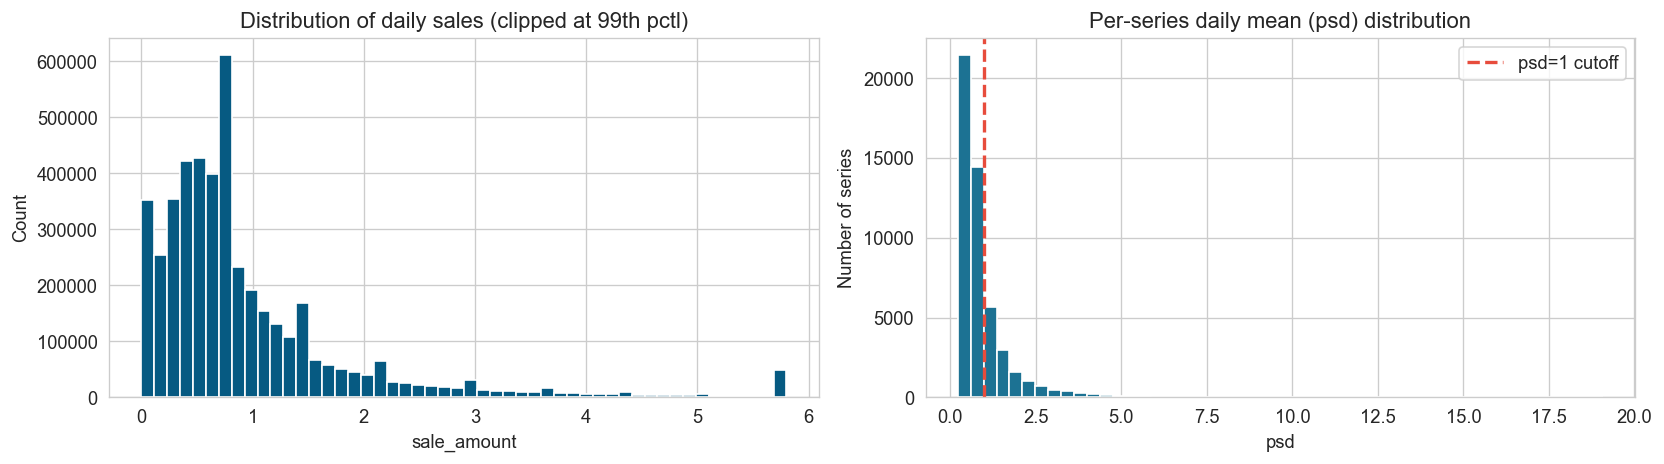

In [10]:
# Sales distribution and per-series daily mean
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

clipped = history["sale_amount"].clip(upper=history["sale_amount"].quantile(0.99))
axes[0].hist(clipped, bins=50, color="#065A82", edgecolor="white")
axes[0].set_title("Distribution of daily sales (clipped at 99th pctl)")
axes[0].set_xlabel("sale_amount")
axes[0].set_ylabel("Count")

psd_vals = history.groupby("series_id")["psd"].first()
axes[1].hist(psd_vals, bins=50, color="#1C7293", edgecolor="white")
axes[1].axvline(1.0, color="#E74C3C", linestyle="--", linewidth=2, label="psd=1 cutoff")
axes[1].set_title("Per-series daily mean (psd) distribution")
axes[1].set_xlabel("psd")
axes[1].set_ylabel("Number of series")
axes[1].legend()

plt.tight_layout()
plt.show()

---
---
# OPERATIONS TRACK

## 5. Operations Track

> **You may skip this section if you are focusing on the Data Science track.**

This section produces the following outputs — each corresponds to a slide in the deck:

| Output | What it shows | Slide |
|--------|--------------|-------|
| Temporal profiles (3 line charts) | Mean sales, stockout hours, and censoring share over 90 days | Slide 10 |
| City × group heatmap | Where stockouts concentrate geographically | Slide 11 |
| Availability bar chart | Which cities have the worst service levels | Slide 11 |
| Hourly stockout bar chart | How stockouts accumulate through the day | Slide 12 |
| Dual-axis time series | One product's sales overlaid with stockout hours | Slide 12 |

**A strong operations project** extends these starter visualizations into a focused analysis that answers one clear question (O1 or O2).

### 5a. EDA Strategy: Where to Look

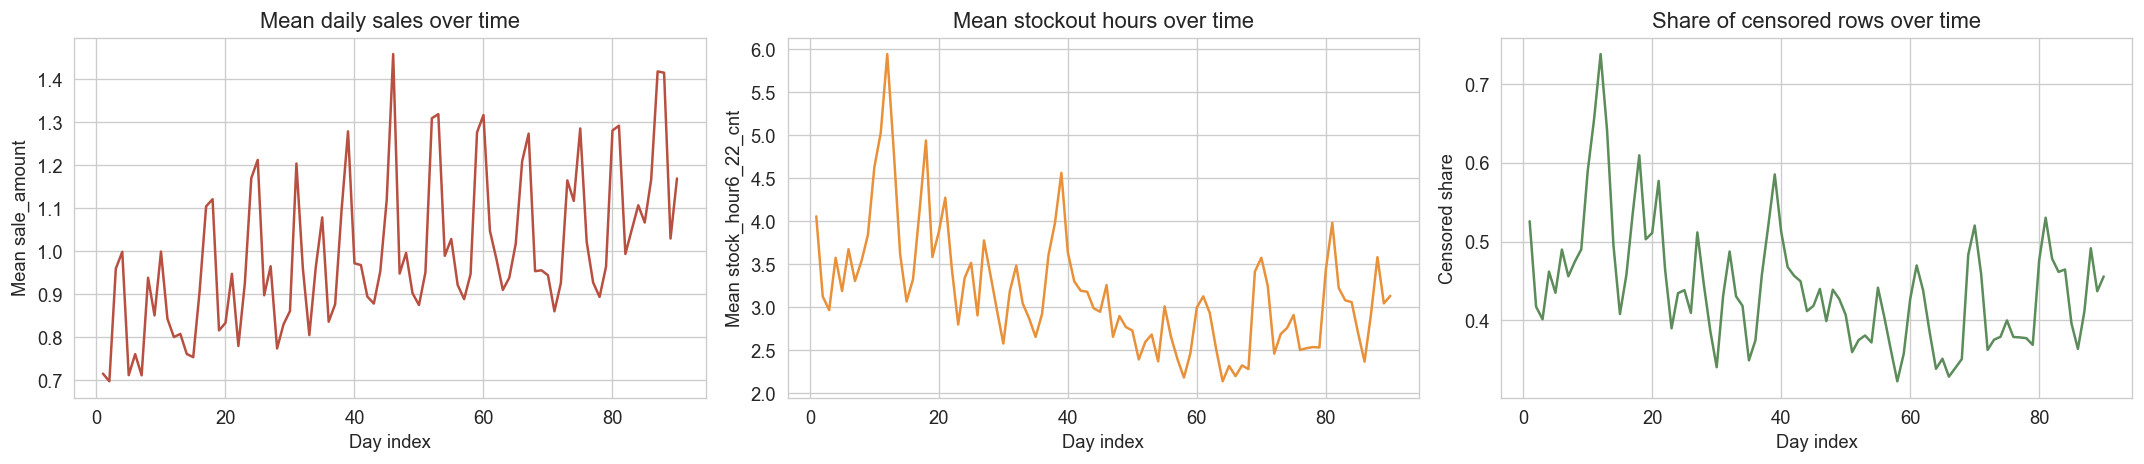

In [11]:
# --- Temporal profiles ---
daily_profile = history.groupby("day_idx").agg(
    mean_sales=("sale_amount", "mean"),
    mean_stockout_hours=("stock_hour6_22_cnt", "mean"),
    censored_share=("is_censored", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(daily_profile["day_idx"], daily_profile["mean_sales"], color="#B85042", linewidth=1.5)
axes[0].set_title("Mean daily sales over time")
axes[0].set_xlabel("Day index")
axes[0].set_ylabel("Mean sale_amount")

axes[1].plot(daily_profile["day_idx"], daily_profile["mean_stockout_hours"], color="#E8913A", linewidth=1.5)
axes[1].set_title("Mean stockout hours over time")
axes[1].set_xlabel("Day index")
axes[1].set_ylabel("Mean stock_hour6_22_cnt")

axes[2].plot(daily_profile["day_idx"], daily_profile["censored_share"], color="#5B8C5A", linewidth=1.5)
axes[2].set_title("Share of censored rows over time")
axes[2].set_xlabel("Day index")
axes[2].set_ylabel("Censored share")

plt.tight_layout()
plt.show()

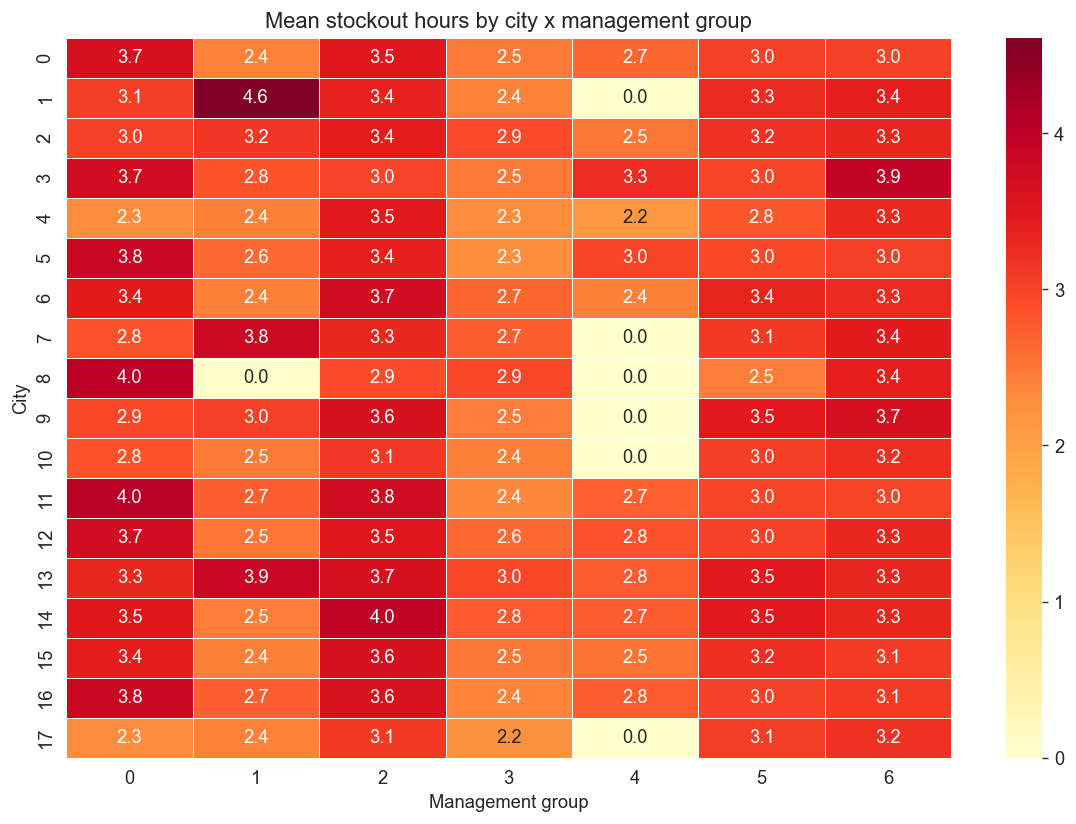

In [12]:
# --- Heatmap: stockout hours by city x management group ---
heatmap_data = history.groupby(["city_id", "management_group_id"])["stock_hour6_22_cnt"].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=True, fmt=".1f", ax=ax, linewidths=0.5)
ax.set_title("Mean stockout hours by city x management group")
ax.set_xlabel("Management group")
ax.set_ylabel("City")
plt.tight_layout()
plt.show()

### 5b. EDA Strategy: What to Measure

In [13]:
# --- Operational KPIs per series ---
series_kpis = history.groupby("series_id").agg(
    psd=("sale_amount", "mean"),
    stockout_frequency=("is_censored", "mean"),
    mean_stockout_hours=("stock_hour6_22_cnt", "mean"),
    availability_rate=("censoring_severity", "mean"),
    city=("city_id", "first"),
    mgmt_group=("management_group_id", "first"),
).reset_index()

# Convert from mean censoring severity to availability rate
series_kpis["availability_rate"] = 1 - series_kpis["availability_rate"]

print("=== Series-level KPI summary ===")
display(series_kpis[["psd", "stockout_frequency", "mean_stockout_hours", "availability_rate"]].describe().round(3))

=== Series-level KPI summary ===


,psd,stockout_frequency,mean_stockout_hours,availability_rate
count,50000.000,50000.000,50000.000,50000.000
mean,0.999,0.443,3.180,0.801
std,1.153,0.148,1.314,0.082
min,0.222,0.056,0.622,0.030
25%,0.494,0.344,2.378,0.781
50%,0.658,0.422,2.828,0.823
75%,1.054,0.522,3.511,0.851
max,19.074,1.000,15.522,0.961


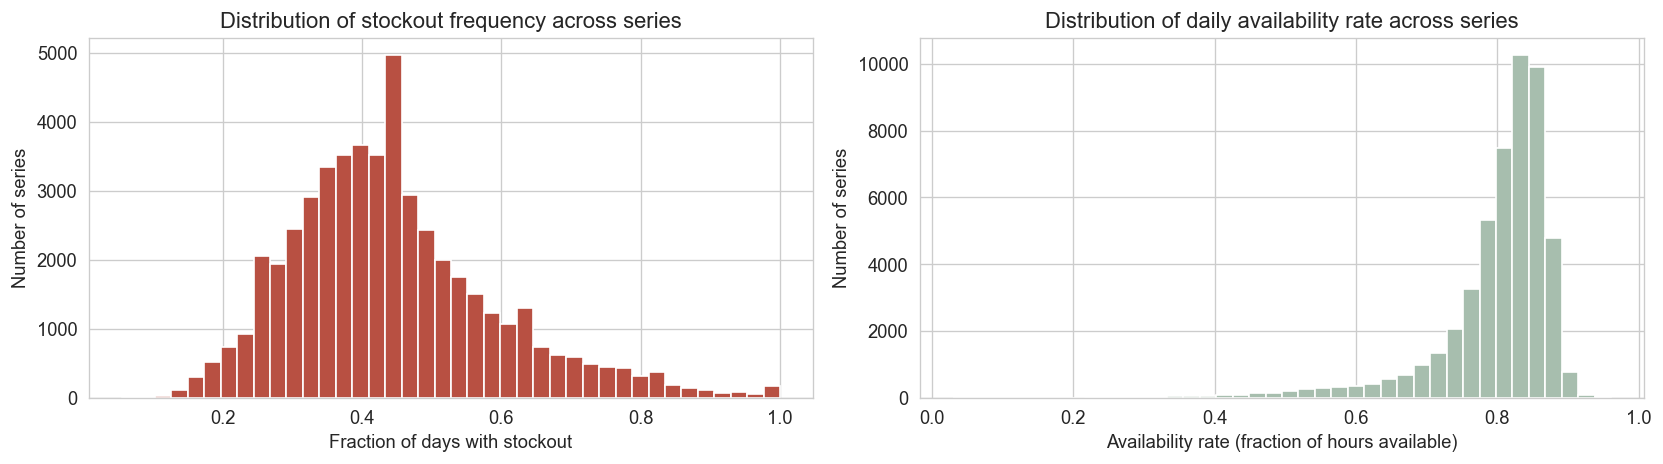

In [14]:
# --- Distribution of stockout frequency and availability ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(series_kpis["stockout_frequency"], bins=40, color="#B85042", edgecolor="white")
axes[0].set_title("Distribution of stockout frequency across series")
axes[0].set_xlabel("Fraction of days with stockout")
axes[0].set_ylabel("Number of series")

axes[1].hist(series_kpis["availability_rate"], bins=40, color="#A7BEAE", edgecolor="white")
axes[1].set_title("Distribution of daily availability rate across series")
axes[1].set_xlabel("Availability rate (fraction of hours available)")
axes[1].set_ylabel("Number of series")

plt.tight_layout()
plt.show()

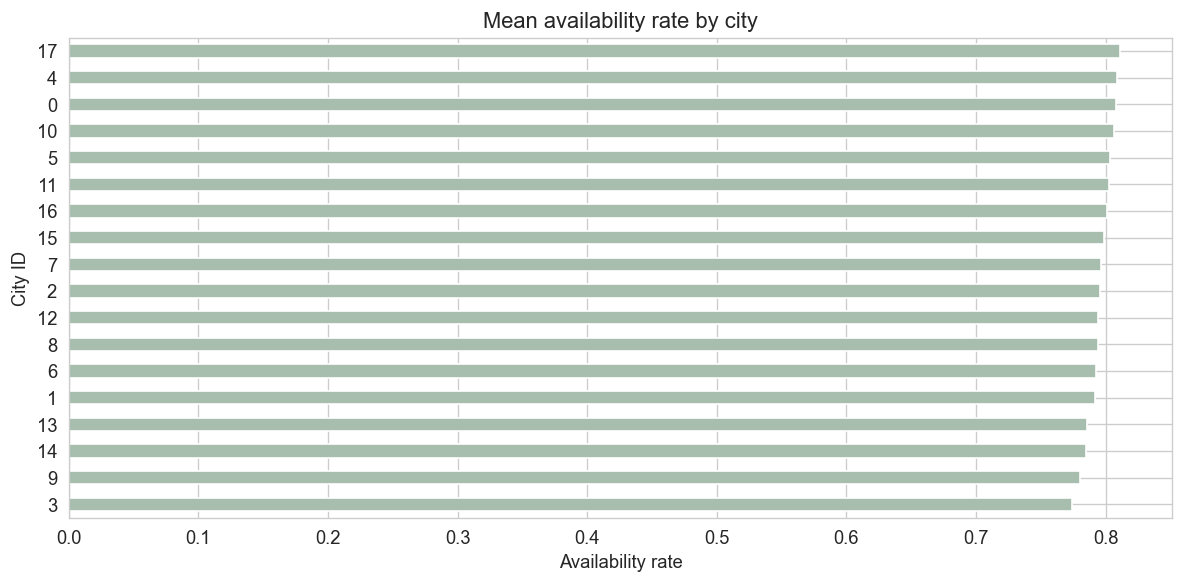

In [15]:
# --- Availability by city ---
city_avail = series_kpis.groupby("city")["availability_rate"].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
city_avail.plot(kind="barh", color="#A7BEAE", edgecolor="white", ax=ax)
ax.set_title("Mean availability rate by city")
ax.set_xlabel("Availability rate")
ax.set_ylabel("City ID")
plt.tight_layout()
plt.show()

### 5c. Hourly Stockout Patterns

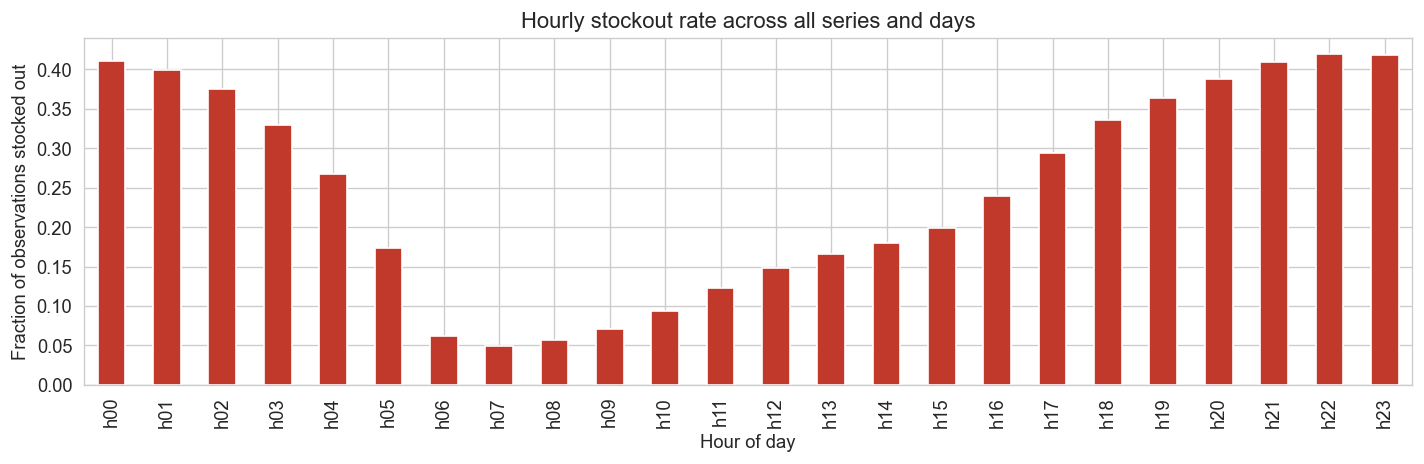

In [16]:
# Expand hourly stock status to compute hourly stockout rates
hourly_stock = np.stack(history["hours_stock_status"].values)
hourly_labels = [f"h{h:02d}" for h in range(24)]
hourly_stockout_rate = pd.Series(hourly_stock.mean(axis=0), index=hourly_labels)

fig, ax = plt.subplots(figsize=(12, 4))
hourly_stockout_rate.plot(kind="bar", color="#C0392B", edgecolor="white", ax=ax)
ax.set_title("Hourly stockout rate across all series and days")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Fraction of observations stocked out")
plt.tight_layout()
plt.show()

### 5d. Example: One Product Over Time

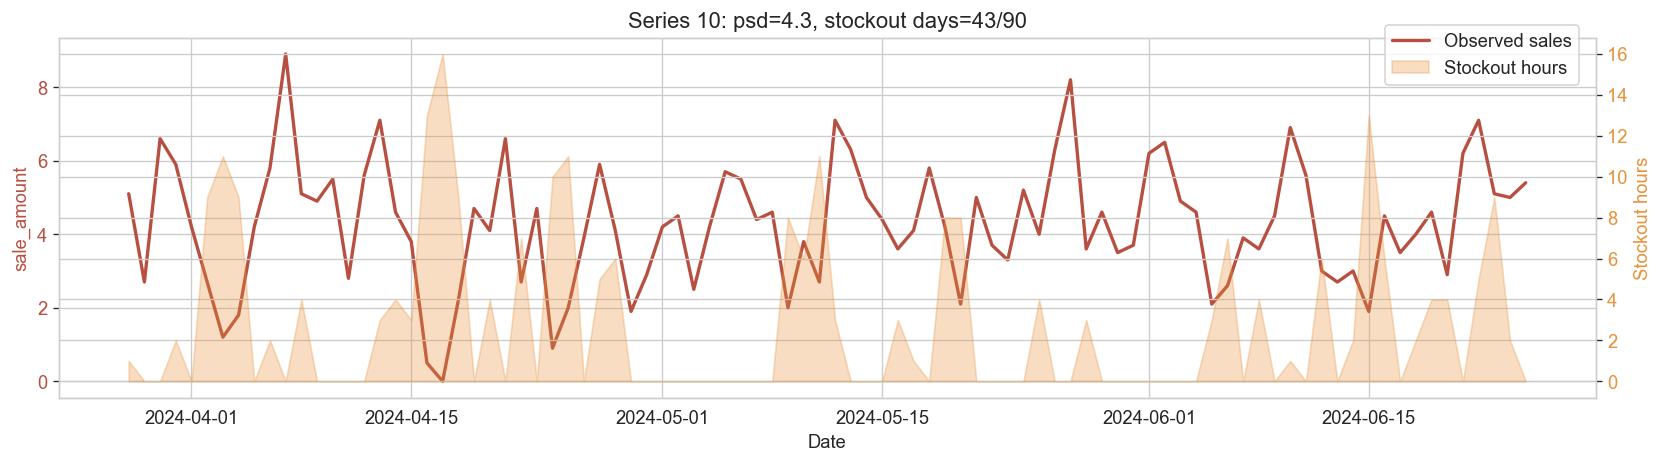

In [17]:
# Pick a high-sale series with some stockouts
high_stockout = series_kpis[(series_kpis["psd"] > 3) & (series_kpis["stockout_frequency"] > 0.3)]
if len(high_stockout) > 0:
    example_sid2 = high_stockout.iloc[0]["series_id"]
else:
    example_sid2 = history.groupby("series_id")["psd"].first().idxmax()

example = history[history["series_id"] == example_sid2].copy()
n_days = len(example)

fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(example["dt"], example["sale_amount"], color="#B85042", linewidth=2, label="Observed sales")
ax1.set_xlabel("Date")
ax1.set_ylabel("sale_amount", color="#B85042")
ax1.tick_params(axis="y", labelcolor="#B85042")

ax2 = ax1.twinx()
ax2.fill_between(example["dt"], 0, example["stock_hour6_22_cnt"], alpha=0.3, color="#E8913A", label="Stockout hours")
ax2.set_ylabel("Stockout hours", color="#E8913A")
ax2.tick_params(axis="y", labelcolor="#E8913A")

ax1.set_title(f"Series {int(example_sid2)}: psd={example['psd'].iloc[0]:.1f}, stockout days={int(example['is_censored'].sum())}/{n_days}")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

---
---
# DATA SCIENCE TRACK

## 6. Data Science Track

> **You may skip this section if you are focusing on the Operations track.**

This section produces the following outputs — each corresponds to a slide in the deck:

| Output | What it shows | Slide |
|--------|--------------|-------|
| WAPE results table (D1) | Baseline comparison: global mean vs seasonal naive vs rolling 28d | Slide 18 |
| Forecast overlay chart | Predicted vs actual for one series across the validation window | Slide 18 |
| Recovery comparison table (D2) | WAPE on raw vs corrected target — does imputation help? | Slide 19 |
| WAPE by management group | Which product groups are hardest to forecast? | Slide 20 |
| Residual histogram + error scatter | Where the model fails and why | Slide 20 |

**A strong data science project** starts from these baselines and improves on them with better features, better imputation, or a more sophisticated model — always measured by WAPE on the same time split.

### 6a. WAPE Evaluation Function

In [18]:
def compute_wape(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Weighted Absolute Percentage Error."""
    denom = np.sum(np.abs(actual))
    if denom == 0:
        return np.nan
    return np.sum(np.abs(actual - predicted)) / denom


def evaluate_forecast(val_df: pd.DataFrame, pred_col: str = "prediction") -> dict:
    """Compute WAPE overall, low-sale, high-sale, and harmonic mean.
    Only evaluates rows where stock_hour6_22_cnt == 0 (uncensored in validation)."""
    scored = val_df[val_df["stock_hour6_22_cnt"] == 0].copy()
    if len(scored) == 0:
        return {"wape_overall": np.nan}

    y = scored["sale_amount"].values
    yhat = scored[pred_col].values

    wape_all = compute_wape(y, yhat)

    low = scored[scored["psd"] < 1]
    high = scored[scored["psd"] >= 1]

    wape_low = compute_wape(low["sale_amount"].values, low[pred_col].values) if len(low) > 0 else np.nan
    wape_high = compute_wape(high["sale_amount"].values, high[pred_col].values) if len(high) > 0 else np.nan

    if np.isnan(wape_low) or np.isnan(wape_high) or wape_all == 0 or wape_low == 0 or wape_high == 0:
        hm = np.nan
    else:
        hm = 3 / (1/wape_all + 1/wape_low + 1/wape_high)

    return {
        "wape_overall": round(wape_all, 4) if not np.isnan(wape_all) else np.nan,
        "wape_low_sale": round(wape_low, 4) if not np.isnan(wape_low) else np.nan,
        "wape_high_sale": round(wape_high, 4) if not np.isnan(wape_high) else np.nan,
        "harmonic_mean": round(hm, 4) if not np.isnan(hm) else np.nan,
        "scored_rows": len(scored),
    }

print("Evaluation function ready.")

Evaluation function ready.


### 6b. D1 \u2014 Direct Benchmark: Naive Baselines on Raw Sales

In [19]:
# --- Baseline 1: Global mean ---
series_mean = train.groupby("series_id")["sale_amount"].mean().rename("pred_global_mean")
val = val.drop(columns=["pred_global_mean", "pred_seasonal_naive", "pred_roll28", "forecast_day"], errors="ignore")
val = val.merge(series_mean, on="series_id", how="left")

# --- Baseline 2: Seasonal naive (last-week repeat) ---
val_start = val["day_idx"].min()
last_week = history[history["day_idx"].between(val_start - 7, val_start - 1)][["series_id", "day_idx", "sale_amount"]].copy()
last_week["forecast_day"] = last_week["day_idx"] + 7
last_week = last_week.rename(columns={"sale_amount": "pred_seasonal_naive"})

val = val.merge(last_week[["series_id", "forecast_day", "pred_seasonal_naive"]],
                left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"], how="left")
val = val.drop(columns=["forecast_day"], errors="ignore")
val["pred_seasonal_naive"] = val["pred_seasonal_naive"].fillna(val["pred_global_mean"])

# --- Baseline 3: Rolling 28-day mean ---
roll28 = train.groupby("series_id")["sale_amount"].apply(
    lambda x: x.tail(28).mean(), include_groups=False
).rename("pred_roll28")
val = val.merge(roll28, on="series_id", how="left")

# Evaluate all three
results = {}
for method, col in [("Global mean", "pred_global_mean"), ("Seasonal naive", "pred_seasonal_naive"), ("Rolling 28d", "pred_roll28")]:
    val["prediction"] = val[col].clip(lower=0)
    results[method] = evaluate_forecast(val)

results_df = pd.DataFrame(results).T
print("=== D1 Benchmark Results ===")
display(results_df)

=== D1 Benchmark Results ===


,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
Global mean,0.4336,0.4508,0.4203,0.4345,198987.0
Seasonal naive,0.3976,0.4830,0.3317,0.3947,198987.0
Rolling 28d,0.3637,0.4143,0.3247,0.3639,198987.0


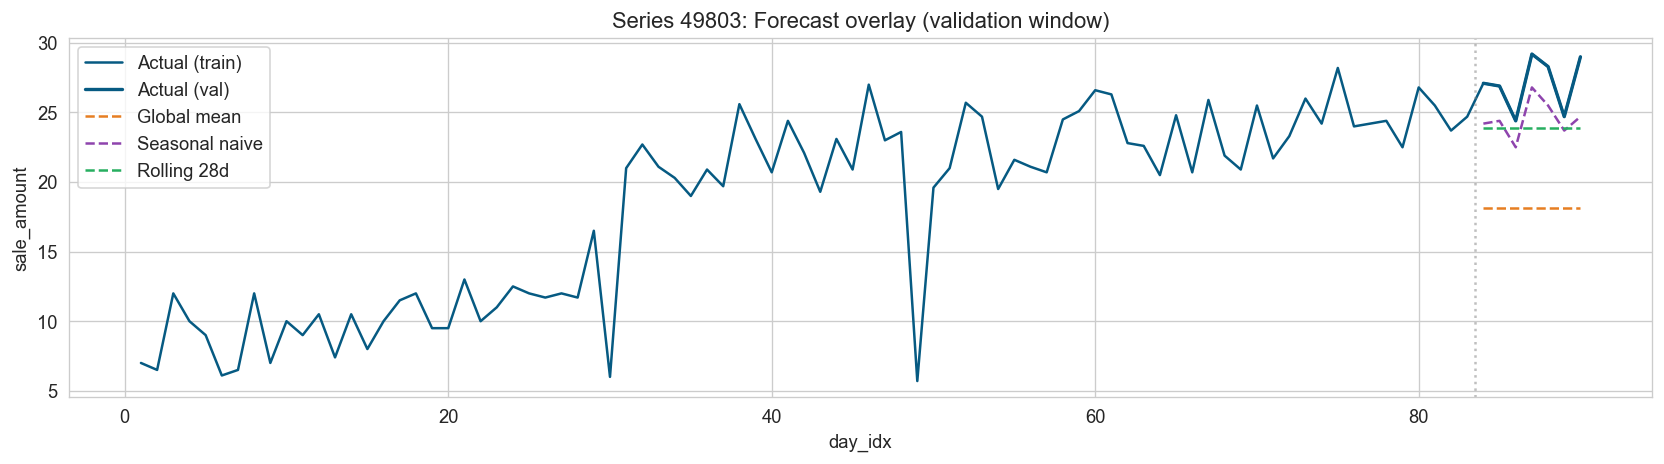

In [20]:
# --- Visualize: forecast overlay for one series ---
example_sid3 = history.groupby("series_id")["psd"].first().sort_values(ascending=False).index[5]
ex = history[history["series_id"] == example_sid3].copy()
ex_val = val[val["series_id"] == example_sid3].copy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ex["day_idx"], ex["sale_amount"], color="#065A82", linewidth=1.5, label="Actual (train)")
ax.plot(ex_val["day_idx"], ex_val["sale_amount"], color="#065A82", linewidth=2, linestyle="-", label="Actual (val)")
ax.plot(ex_val["day_idx"], ex_val["pred_global_mean"], color="#E67E22", linewidth=1.5, linestyle="--", label="Global mean")
ax.plot(ex_val["day_idx"], ex_val["pred_seasonal_naive"], color="#8E44AD", linewidth=1.5, linestyle="--", label="Seasonal naive")
ax.plot(ex_val["day_idx"], ex_val["pred_roll28"], color="#27AE60", linewidth=1.5, linestyle="--", label="Rolling 28d")

ax.axvline(ex_val["day_idx"].min() - 0.5, color="gray", linestyle=":", alpha=0.5)
ax.set_title(f"Series {example_sid3}: Forecast overlay (validation window)")
ax.set_xlabel("day_idx")
ax.set_ylabel("sale_amount")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 6c. D2 \u2014 Recovery First: Impute Censored Hours, Then Forecast

In [27]:
# Expand hourly data from the list columns
# Note: this creates large arrays (~550MB). Colab free tier (12GB RAM) handles this fine.
print("Expanding hourly data...")

hourly_sales = np.stack(history["hours_sale"].values)          # (N, 24)
hourly_stock_ds = np.stack(history["hours_stock_status"].values)  # (N, 24)

# Focus on operating window h06..h21 (indices 6..21, 16 hours)
op_sales = hourly_sales[:, 6:22].astype(np.float32)
op_stock_status = hourly_stock_ds[:, 6:22].astype(np.float32)

# Mark censored hours
op_sales_masked = np.where(op_stock_status == 1, np.nan, op_sales) # sales, but stockout sales are censored

total_cells = op_sales_masked.size
missing_cells = np.isnan(op_sales_masked).sum()
print(f"Operating window: {op_sales_masked.shape[1]} hours (h06-h21)")
print(f"Missing hourly cells: {missing_cells:,} / {total_cells:,} ({missing_cells/total_cells:.1%})")

visible_sum = np.nansum(np.where(op_stock_status == 0, op_sales, 0), axis=1) # all sales where enough stock was available
sales_with_stockout = np.maximum(visible_sum - history["sale_amount"].values.astype(np.float32), 0) # need to be subtracted later, because those are calculated again

Expanding hourly data...
Operating window: 16 hours (h06-h21)
Missing hourly cells: 14,311,536 / 72,000,000 (19.9%)


In [29]:
import importlib
import recovery

importlib.reload(recovery)

#recovery.per_series_mean()
recovery.random_sampling(history, op_sales_masked, sales_with_stockout, rng)

Imputed 14,311,536 hourly cells
Mean raw sale_amount: 0.9986
Mean recovered sales: 1.1337


In [ ]:
# Re-split with recovered target
train_r, val_r = time_split(history, horizon=7)

# Seasonal naive on recovered target
val_start_r = val_r["day_idx"].min()
last_week_r = history[history["day_idx"].between(val_start_r - 7, val_start_r - 1)][
    ["series_id", "day_idx", "recovered_daily_sales"]
].copy()
last_week_r["forecast_day"] = last_week_r["day_idx"] + 7
last_week_r = last_week_r.rename(columns={"recovered_daily_sales": "pred_recovered_naive"})

val_r = val_r.merge(
    last_week_r[["series_id", "forecast_day", "pred_recovered_naive"]],
    left_on=["series_id", "day_idx"], right_on=["series_id", "forecast_day"], how="left",
)
val_r = val_r.drop(columns=["forecast_day"], errors="ignore")
fallback = train_r.groupby("series_id")["recovered_daily_sales"].mean()
val_r["pred_recovered_naive"] = val_r["pred_recovered_naive"].fillna(val_r["series_id"].map(fallback))

# Also add seasonal naive on raw for fair comparison
val_r = val_r.merge(
    val[["series_id", "day_idx", "pred_seasonal_naive"]].drop_duplicates(),
    on=["series_id", "day_idx"], how="left",
)

# Evaluate both
d2_results = {}
for method, col in [("Seasonal naive (raw)", "pred_seasonal_naive"), ("Seasonal naive (recovered)", "pred_recovered_naive")]:
    val_r["prediction"] = val_r[col].clip(lower=0)
    d2_results[method] = evaluate_forecast(val_r)

d2_df = pd.DataFrame(d2_results).T
print("=== D2 Recovery Comparison ===")
display(d2_df)

Train: day 1..83 (4,150,000 rows), Val: day 84..90 (350,000 rows)
=== D2 Recovery Comparison ===


,wape_overall,wape_low_sale,wape_high_sale,harmonic_mean,scored_rows
Seasonal naive (raw),0.3976,0.4830,0.3317,0.3947,198987.0
Seasonal naive (recovered),0.4325,0.5791,0.3191,0.4182,198987.0


### 6d. Error Analysis

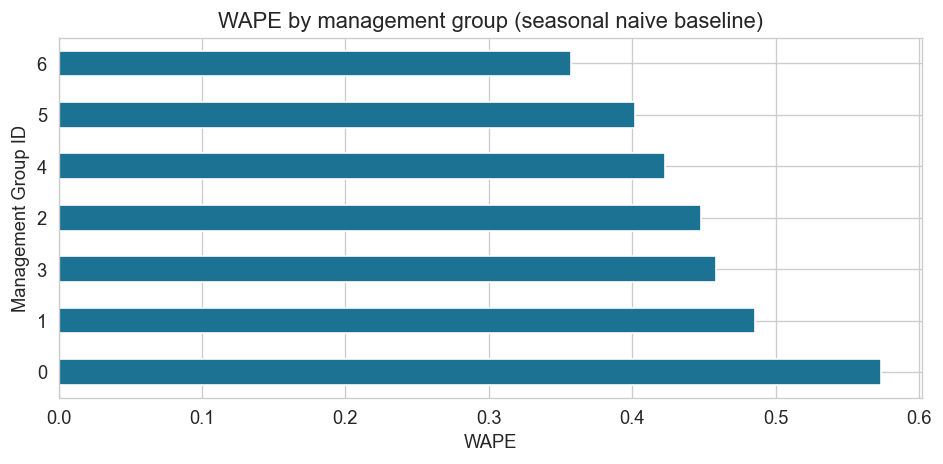

In [ ]:
# WAPE by management group
scored = val[val["stock_hour6_22_cnt"] == 0].copy()
scored["prediction"] = scored["pred_seasonal_naive"].clip(lower=0)
scored["abs_error"] = np.abs(scored["sale_amount"] - scored["prediction"])

group_wape = scored.groupby("management_group_id").apply(
    lambda g: compute_wape(g["sale_amount"].values, g["prediction"].values),
    include_groups=False
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
group_wape.plot(kind="barh", color="#1C7293", edgecolor="white", ax=ax)
ax.set_title("WAPE by management group (seasonal naive baseline)")
ax.set_xlabel("WAPE")
ax.set_ylabel("Management Group ID")
plt.tight_layout()
plt.show()

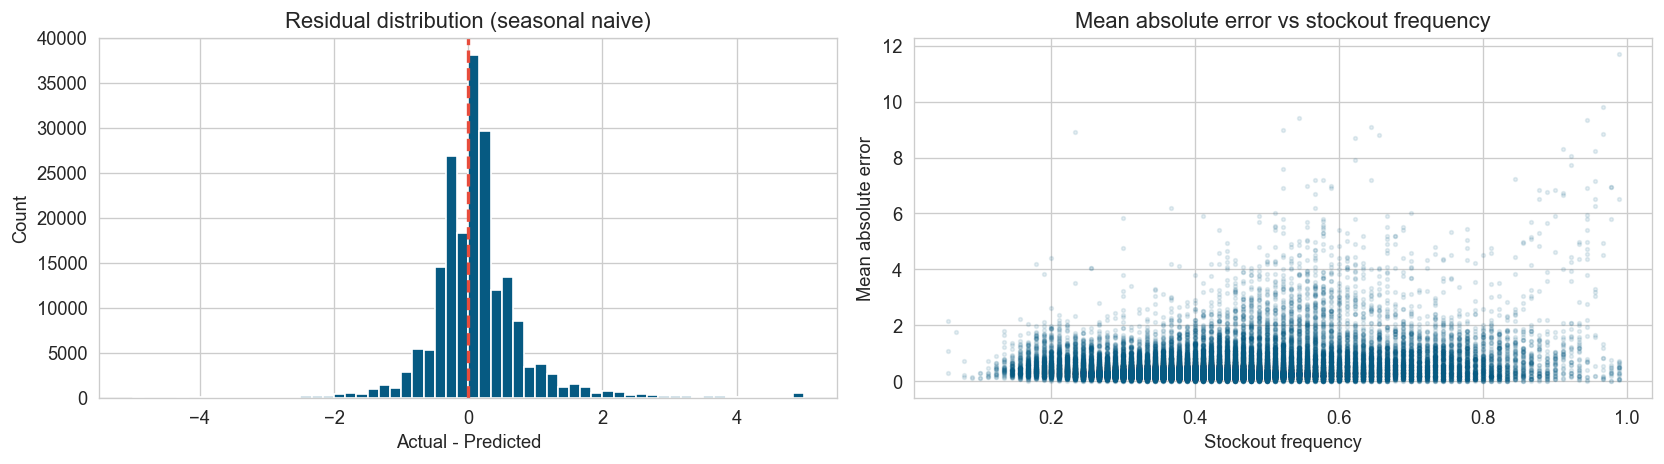

In [ ]:
# Residual distribution and error vs stockout frequency
scored["residual"] = scored["sale_amount"] - scored["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scored["residual"].clip(-5, 5), bins=60, color="#065A82", edgecolor="white")
axes[0].axvline(0, color="#E74C3C", linestyle="--", linewidth=2)
axes[0].set_title("Residual distribution (seasonal naive)")
axes[0].set_xlabel("Actual - Predicted")
axes[0].set_ylabel("Count")

series_error = scored.groupby("series_id").agg(
    mean_abs_error=("abs_error", "mean"),
).reset_index()
series_error = series_error.merge(
    history.groupby("series_id")["is_censored"].mean().rename("stockout_freq"),
    on="series_id"
)
axes[1].scatter(series_error["stockout_freq"], series_error["mean_abs_error"], alpha=0.1, s=5, color="#065A82")
axes[1].set_title("Mean absolute error vs stockout frequency")
axes[1].set_xlabel("Stockout frequency")
axes[1].set_ylabel("Mean absolute error")

plt.tight_layout()
plt.show()

---
---
## 7. Next Steps

### Operations Track

**O1 \u2014 Diagnosis First**
- Extend the heatmaps to find which store x category combinations are most fragile
- Test whether promotions (`discount < 1`) increase late-day stockouts
- Run panel regressions with fixed effects to isolate drivers

**O2 \u2014 Decision First**
- Build a simple corrected demand estimate (impute censored hours from `hours_sale`)
- Compute newsvendor order quantities under raw vs. corrected demand
- Visualize the service vs. waste trade-off curve

### Data Science Track

**D1 \u2014 Direct Benchmark**
- Try exponential smoothing or a simple LightGBM with lag features
- Analyze errors by day-of-week to detect weekly patterns
- Compare WAPE across cities to find geographic patterns

**D2 \u2014 Recovery First**
- Try per-series mean imputation instead of global pool sampling
- Compare multiple recovery strategies on the same baseline
- Focus error analysis on high-stockout series where recovery matters most

### Cross-Track Synergies
- Operations insights (which products are most fragile) can inform DS feature engineering
- DS demand recovery estimates can feed back into operations policy evaluation
- Both tracks benefit from understanding the hourly censoring structure

Data Science
D1: 
- Exponential smoothing (1,2,3), https://www.geeksforgeeks.org/machine-learning/time-series-using-lightgbm/
- Tages_index (mo - so)
- which cities have highest wapes (patterns?)
D2: Recover Data for Stockouts 
- Impute with per-series mean
- Compare multiple recover strategies
- focus error analysis on high-stockout series where recovery matters most